## Schema Overview 

In [1]:
import pandas as pd

mobility = pd.read_parquet(
    "/work/pipeline_data/3.5.1.final_social_integration_package/mobility_anomaly_companion.parquet"
)

print(mobility.shape)
print(mobility.columns.tolist())
mobility.head()

(10741, 44)
['modeling_row_id', 'feature_set', 'date', 'temporal_bucket', 'pre_post_cp', 'taxi_zone_id', 'zone', 'borough', 'policy_geography_class', 'dbscan_all_anomaly_flag', 'gmm_all_anomaly_flag', 'if_all_anomaly_flag', 'dbscan_congestion_anomaly_flag', 'gmm_congestion_anomaly_flag', 'if_congestion_anomaly_flag', 'dbscan_positive_demand_anomaly_flag', 'gmm_positive_demand_anomaly_flag', 'if_positive_demand_anomaly_flag', 'all_anomaly_method_count', 'congestion_anomaly_method_count', 'positive_demand_anomaly_method_count', 'all_anomaly_exact_family', 'congestion_anomaly_exact_family', 'positive_demand_anomaly_exact_family', 'all_anomaly_two_plus_consensus_flag', 'all_anomaly_three_method_consensus_flag', 'congestion_anomaly_two_plus_consensus_flag', 'congestion_anomaly_three_method_consensus_flag', 'positive_demand_anomaly_two_plus_consensus_flag', 'positive_demand_anomaly_three_method_consensus_flag', 'retained_congestion_surface_flag', 'retained_positive_demand_surface_flag', 'ret

,modeling_row_id,feature_set,date,temporal_bucket,pre_post_cp,taxi_zone_id,zone,borough,policy_geography_class,dbscan_all_anomaly_flag,...,directional_label,ambiguous_reason,positive_direction_two_plus_consensus_flag,positive_direction_three_method_consensus_flag,positive_direction_consensus_method_count,handoff_recommended_layer,is_high_confidence_core,is_positive_direction_companion,is_congestion_oriented_lens,is_positive_demand_shock_lens
0,664163,fhvhv,2023-01-01,weekend_overnight,pre_cp,116,Hamilton Heights,Manhattan,outside,1,...,positive_demand_shock,,False,False,1,positive_direction_companion,False,True,False,True
1,741253,fhvhv,2023-01-01,weekend_overnight,pre_cp,129,Jackson Heights,Queens,outside,1,...,positive_demand_shock,,True,False,2,high_confidence_core,True,True,False,True
2,782763,multimodal,2023-01-01,weekend_overnight,pre_cp,136,Kingsbridge Heights,Bronx,outside,1,...,positive_demand_shock,,True,False,2,high_confidence_core,True,True,False,True
3,818343,taxi,2023-01-01,weekend_overnight,pre_cp,142,Lincoln Square East,Manhattan,gateway_or_adjacent,1,...,positive_demand_shock,,True,True,3,high_confidence_core,True,True,False,True
4,871713,taxi,2023-01-01,weekend_overnight,pre_cp,151,Manhattan Valley,Manhattan,outside,1,...,positive_demand_shock,,True,False,2,high_confidence_core,True,True,False,True


In [3]:
reddit = pd.read_parquet(
    "/work/Reddit/stance_predictions_modernbert.parquet"
)

print(reddit.shape)
print(reddit.columns.tolist())
reddit.head()

(427036, 10)
['id', 'kind', 'subreddit', 'created_utc', 'link_id', 'stance_pred', 'p_anti', 'p_neutral', 'p_pro', 'p_off_topic']


,id,kind,subreddit,created_utc,link_id,stance_pred,p_anti,p_neutral,p_pro,p_off_topic
0,mllrojk,comment,astoria,1743889388,t3_1huc1aj,anti,0.714919,0.084720,0.004817,0.195543
1,mln4rd6,comment,astoria,1743908407,t3_1huc1aj,off-topic,0.151928,0.087929,0.018145,0.741997
2,mlqortk,comment,astoria,1743965221,t3_1jt0l93,off-topic,0.064143,0.005024,0.017264,0.913570
3,mlqr4g0,comment,astoria,1743965978,t3_1jt0l93,off-topic,0.053330,0.005732,0.021131,0.919807
4,mlqr8wx,comment,astoria,1743966018,t3_1jt0l93,off-topic,0.007842,0.001998,0.002373,0.987786


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

# Project branding
from project_branding import (
    BRAND_COLORS,
    BRAND_COLOR_SEQUENCE,
    BRAND_DIVERGING_SEQUENCE,
    BRAND_MAP_COLORS,
)

px.defaults.template = "plotly_white"
px.defaults.color_discrete_sequence = BRAND_COLOR_SEQUENCE


plt.style.use("default")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=BRAND_COLOR_SEQUENCE)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["legend.frameon"] = False

## How do mobility anomalies correspond to changes in online discussion and stance surrounding congestion pricing?

In [7]:
import numpy as np
import matplotlib.pyplot as plt

mobility_path = "/work/pipeline_data/3.5.1.final_social_integration_package/mobility_anomaly_companion.parquet"
reddit_path = "/work/Reddit/stance_predictions_modernbert.parquet"

mobility = pd.read_parquet(mobility_path)
reddit = pd.read_parquet(reddit_path)

mobility["date"] = pd.to_datetime(mobility["date"]).dt.date
reddit["created_dt"] = pd.to_datetime(reddit["created_utc"], unit="s", errors="coerce")
reddit["date"] = reddit["created_dt"].dt.date

print(mobility.shape)
print(reddit.shape)
display(mobility.head())
display(reddit.head())

(10741, 44)
(427036, 12)


,modeling_row_id,feature_set,date,temporal_bucket,pre_post_cp,taxi_zone_id,zone,borough,policy_geography_class,dbscan_all_anomaly_flag,...,directional_label,ambiguous_reason,positive_direction_two_plus_consensus_flag,positive_direction_three_method_consensus_flag,positive_direction_consensus_method_count,handoff_recommended_layer,is_high_confidence_core,is_positive_direction_companion,is_congestion_oriented_lens,is_positive_demand_shock_lens
0,664163,fhvhv,2023-01-01,weekend_overnight,pre_cp,116,Hamilton Heights,Manhattan,outside,1,...,positive_demand_shock,,False,False,1,positive_direction_companion,False,True,False,True
1,741253,fhvhv,2023-01-01,weekend_overnight,pre_cp,129,Jackson Heights,Queens,outside,1,...,positive_demand_shock,,True,False,2,high_confidence_core,True,True,False,True
2,782763,multimodal,2023-01-01,weekend_overnight,pre_cp,136,Kingsbridge Heights,Bronx,outside,1,...,positive_demand_shock,,True,False,2,high_confidence_core,True,True,False,True
3,818343,taxi,2023-01-01,weekend_overnight,pre_cp,142,Lincoln Square East,Manhattan,gateway_or_adjacent,1,...,positive_demand_shock,,True,True,3,high_confidence_core,True,True,False,True
4,871713,taxi,2023-01-01,weekend_overnight,pre_cp,151,Manhattan Valley,Manhattan,outside,1,...,positive_demand_shock,,True,False,2,high_confidence_core,True,True,False,True


,id,kind,subreddit,created_utc,link_id,stance_pred,p_anti,p_neutral,p_pro,p_off_topic,created_dt,date
0,mllrojk,comment,astoria,1743889388,t3_1huc1aj,anti,0.714919,0.084720,0.004817,0.195543,2025-04-05 21:43:08,2025-04-05
1,mln4rd6,comment,astoria,1743908407,t3_1huc1aj,off-topic,0.151928,0.087929,0.018145,0.741997,2025-04-06 03:00:07,2025-04-06
2,mlqortk,comment,astoria,1743965221,t3_1jt0l93,off-topic,0.064143,0.005024,0.017264,0.913570,2025-04-06 18:47:01,2025-04-06
3,mlqr4g0,comment,astoria,1743965978,t3_1jt0l93,off-topic,0.053330,0.005732,0.021131,0.919807,2025-04-06 18:59:38,2025-04-06
4,mlqr8wx,comment,astoria,1743966018,t3_1jt0l93,off-topic,0.007842,0.001998,0.002373,0.987786,2025-04-06 19:00:18,2025-04-06


### Daily Reddit Summary Report

In [9]:
reddit_daily = (
    reddit
    .groupby("date")
    .agg(
        reddit_posts=("id", "count"),
        anti_share=("p_anti", "mean"),
        pro_share=("p_pro", "mean"),
        neutral_share=("p_neutral", "mean"),
        off_topic_share=("p_off_topic", "mean"),
        anti_count=("stance_pred", lambda x: (x == "anti").sum()),
        pro_count=("stance_pred", lambda x: (x == "pro").sum()),
        neutral_count=("stance_pred", lambda x: (x == "neutral").sum())
    )
    .reset_index()
)

reddit_daily.head()

,date,reddit_posts,anti_share,pro_share,neutral_share,off_topic_share,anti_count,pro_count,neutral_count
0,2023-01-01,100,0.080058,0.223127,0.037392,0.659423,5,20,1
1,2023-01-02,245,0.057544,0.122598,0.083880,0.735977,10,14,8
2,2023-01-03,279,0.129337,0.220232,0.124264,0.526167,30,58,28
3,2023-01-04,205,0.073346,0.218776,0.021370,0.686509,11,37,2
4,2023-01-05,210,0.108838,0.350818,0.037971,0.502373,16,74,7


### Create Daily Mobility Anomaly Summary

In [11]:
mobility_daily = (
    mobility
    .groupby("date")
    .agg(
        total_mobility_events=("modeling_row_id", "count"),
        high_confidence_events=("is_high_confidence_core", "sum"),
        congestion_events=("retained_congestion_surface_flag", "sum"),
        positive_demand_events=("retained_positive_demand_surface_flag", "sum"),
        positive_direction_events=("retained_positive_direction_surface_flag", "sum"),
        all_anomaly_events=("retained_all_anomaly_surface_flag", "sum"),
        avg_all_method_count=("all_anomaly_method_count", "mean"),
        avg_congestion_method_count=("congestion_anomaly_method_count", "mean")
    )
    .reset_index()
)

mobility_daily.head()

,date,total_mobility_events,high_confidence_events,congestion_events,positive_demand_events,positive_direction_events,all_anomaly_events,avg_all_method_count,avg_congestion_method_count
0,2023-01-01,32,15,3,30,32,32,1.750000,0.156250
1,2023-01-02,4,2,3,1,4,4,1.500000,1.000000
2,2023-01-03,11,5,2,9,11,11,1.727273,0.272727
3,2023-01-04,8,5,3,5,8,8,1.875000,0.625000
4,2023-01-05,6,2,5,1,6,6,2.000000,0.833333


### Join Mobility \+ Reddit by Date

In [13]:
daily = mobility_daily.merge(reddit_daily, on="date", how="inner")
daily["date"] = pd.to_datetime(daily["date"])

daily.head()

,date,total_mobility_events,high_confidence_events,congestion_events,positive_demand_events,positive_direction_events,all_anomaly_events,avg_all_method_count,avg_congestion_method_count,reddit_posts,anti_share,pro_share,neutral_share,off_topic_share,anti_count,pro_count,neutral_count
0,2023-01-01,32,15,3,30,32,32,1.750000,0.156250,100,0.080058,0.223127,0.037392,0.659423,5,20,1
1,2023-01-02,4,2,3,1,4,4,1.500000,1.000000,245,0.057544,0.122598,0.083880,0.735977,10,14,8
2,2023-01-03,11,5,2,9,11,11,1.727273,0.272727,279,0.129337,0.220232,0.124264,0.526167,30,58,28
3,2023-01-04,8,5,3,5,8,8,1.875000,0.625000,205,0.073346,0.218776,0.021370,0.686509,11,37,2
4,2023-01-05,6,2,5,1,6,6,2.000000,0.833333,210,0.108838,0.350818,0.037971,0.502373,16,74,7


### Analysis 1 — Do Mobility Anomalies Align with Reddit Volume?

Goal: Examine long\-term trends in Reddit stance toward congestion pricing and identify whether public sentiment shifted following the implementation of the CBDTP on January 5, 2025\. The 30\-day moving average helps smooth short\-term fluctuations and highlight broader sentiment patterns over time\.

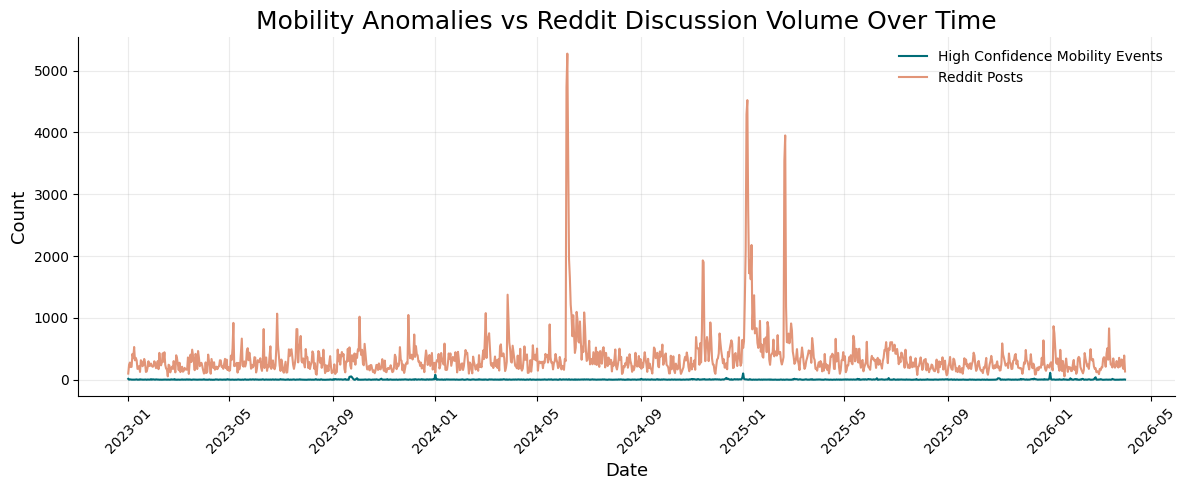

In [15]:
plt.figure(figsize=(12, 5))
plt.plot(daily["date"], daily["high_confidence_events"], label="High Confidence Mobility Events")
plt.plot(daily["date"], daily["reddit_posts"], label="Reddit Posts")
plt.legend()
plt.title("Mobility Anomalies vs Reddit Discussion Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Interpretation: The figure shows that Reddit discussion and mobility anomalies often increase during similar periods, particularly around major transportation disruptions\. However, the relationship is not perfectly synchronized, suggesting that while mobility events contribute to online discussion, other external events also influence Reddit activity\.

Key Takeaway: Periods with elevated mobility anomalies generally coincide with increased Reddit discussion, indicating that transportation disruptions may draw greater public attention even if they are not the sole driver of online conversations\.

### Analysis 2 — Do Anomalies Align with Anti/Pro Sentiment?

Goal: Examine long\-term trends in Reddit stance toward congestion pricing and identify whether public sentiment shifted following the implementation of the CBDTP on January 5, 2025\. The 30\-day moving average helps smooth short\-term fluctuations and highlight broader sentiment patterns over time\.

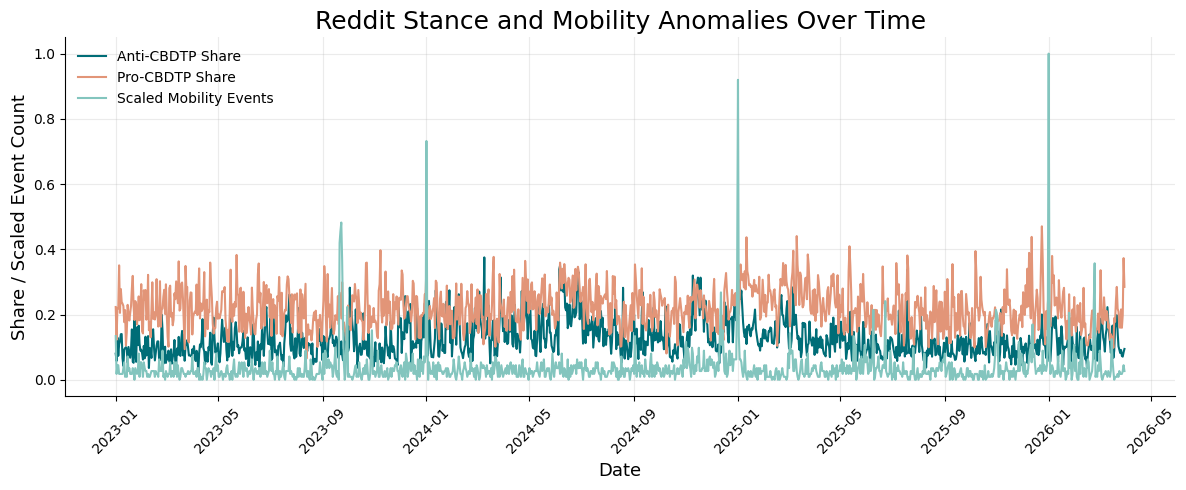

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(daily["date"], daily["anti_share"], label="Anti-CBDTP Share")
plt.plot(daily["date"], daily["pro_share"], label="Pro-CBDTP Share")
plt.plot(daily["date"], daily["high_confidence_events"] / daily["high_confidence_events"].max(), 
         label="Scaled Mobility Events")
plt.legend()
plt.title("Reddit Stance and Mobility Anomalies Over Time")
plt.xlabel("Date")
plt.ylabel("Share / Scaled Event Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

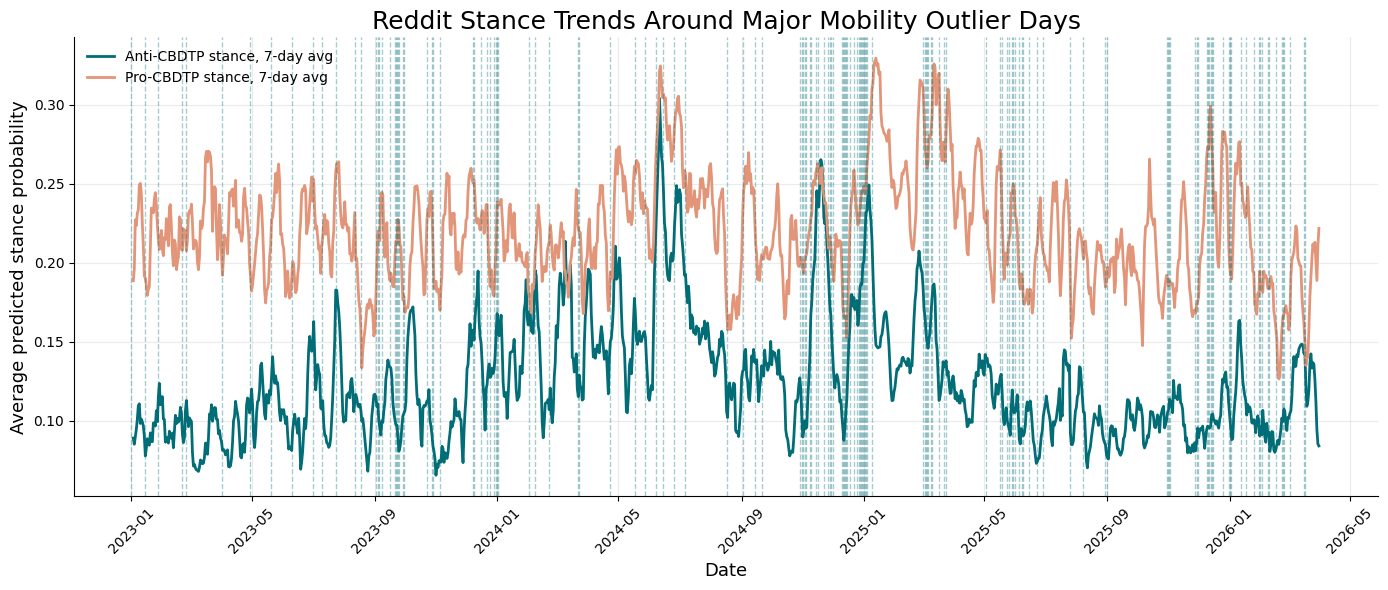

In [19]:
import pandas as pd
import matplotlib.pyplot as plt


daily["date"] = pd.to_datetime(daily["date"])


daily = daily.sort_values("date").copy()
daily["anti_smooth"] = daily["anti_share"].rolling(7, min_periods=3).mean()
daily["pro_smooth"] = daily["pro_share"].rolling(7, min_periods=3).mean()

# only major mobility event days to avoid clutter
threshold = daily["high_confidence_events"].quantile(0.90)

anomaly_dates = daily.loc[
    daily["high_confidence_events"] >= threshold, "date"
]


plt.figure(figsize=(14, 6))

plt.plot(
    daily["date"],
    daily["anti_smooth"],
    label="Anti-CBDTP stance, 7-day avg",
    linewidth=2
)

plt.plot(
    daily["date"],
    daily["pro_smooth"],
    label="Pro-CBDTP stance, 7-day avg",
    linewidth=2
)

for d in anomaly_dates:
    plt.axvline(
        x=d,
        linestyle="--",
        linewidth=1,
        alpha=0.35
    )

plt.title("Reddit Stance Trends Around Major Mobility Outlier Days")
plt.xlabel("Date")
plt.ylabel("Average predicted stance probability")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

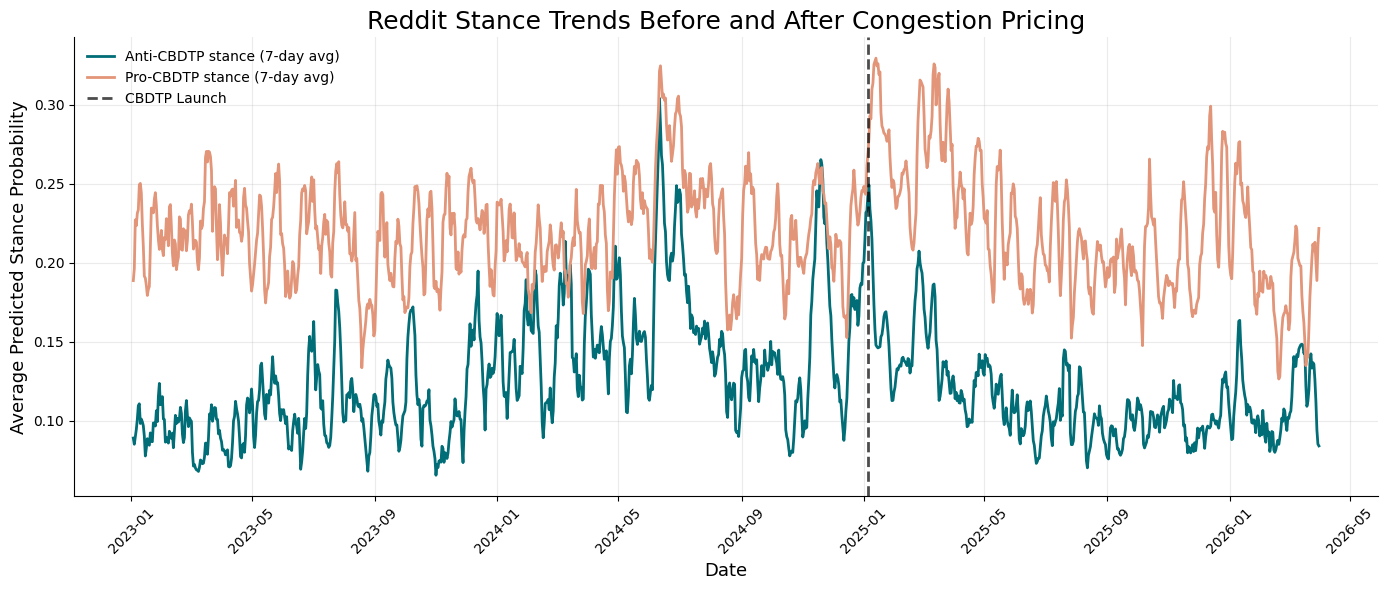

In [21]:
daily["date"] = pd.to_datetime(daily["date"])

daily = daily.sort_values("date").copy()
daily["anti_smooth"] = daily["anti_share"].rolling(7, min_periods=3).mean()
daily["pro_smooth"] = daily["pro_share"].rolling(7, min_periods=3).mean()

plt.figure(figsize=(14, 6))

plt.plot(
    daily["date"],
    daily["anti_smooth"],
    label="Anti-CBDTP stance (7-day avg)",
    linewidth=2
)

plt.plot(
    daily["date"],
    daily["pro_smooth"],
    label="Pro-CBDTP stance (7-day avg)",
    linewidth=2
)

# CBDTP launch
plt.axvline(
    pd.Timestamp("2025-01-05"),
    color="black",
    linestyle="--",
    linewidth=2,
    alpha=0.7,
    label="CBDTP Launch"
)

plt.title("Reddit Stance Trends Before and After Congestion Pricing")
plt.xlabel("Date")
plt.ylabel("Average Predicted Stance Probability")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
daily["anti_smooth_30"] = daily["anti_share"].rolling(
    30,
    min_periods=10
).mean()

daily["pro_smooth_30"] = daily["pro_share"].rolling(
    30,
    min_periods=10
).mean()

Interpretation: Although mobility anomalies fluctuate throughout the study period, the relative balance between pro\- and anti\-CBDTP sentiment remains fairly stable\. Pro\-CBDTP sentiment consistently exceeds anti\-CBDTP sentiment, even during periods with elevated mobility disruptions\.

Key Takeaway: Mobility disruptions do not appear to substantially alter overall public sentiment\. Instead, they occur alongside a relatively stable distribution of opinions toward congestion pricing\.

How did Reddit stance evolve before and after congestion pricing?

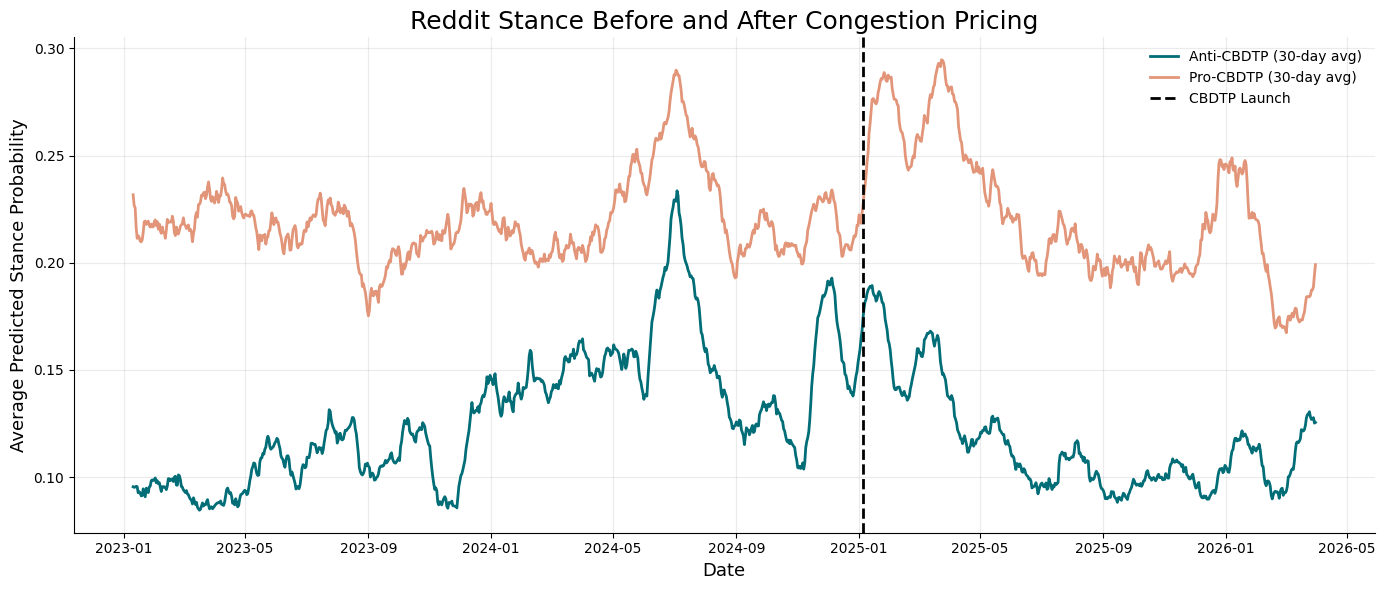

In [25]:
plt.figure(figsize=(14,6))

plt.plot(
    daily["date"],
    daily["anti_smooth_30"],
    label="Anti-CBDTP (30-day avg)",
    linewidth=2
)

plt.plot(
    daily["date"],
    daily["pro_smooth_30"],
    label="Pro-CBDTP (30-day avg)",
    linewidth=2
)

plt.axvline(
    pd.Timestamp("2025-01-05"),
    color="black",
    linestyle="--",
    linewidth=2,
    label="CBDTP Launch"
)

plt.title("Reddit Stance Before and After Congestion Pricing")
plt.xlabel("Date")
plt.ylabel("Average Predicted Stance Probability")
plt.legend()
plt.tight_layout()
plt.show()

Interpretation: The 30\-day moving averages show that both pro\- and anti\-CBDTP sentiment remain relatively consistent before and after implementation\. While short\-term fluctuations are present, there is no sustained shift immediately following policy adoption\.

Key Takeaway: The implementation of congestion pricing did not produce a major long\-term change in Reddit sentiment, suggesting that public opinion remained relatively stable after the policy took effect\.

Did average sentiment change after the policy launched?

In [27]:
pre = daily[daily["date"] < "2025-01-05"]
post = daily[daily["date"] >= "2025-01-05"]

comparison = pd.DataFrame({
    "Period": ["Pre-CBDTP", "Post-CBDTP"],
    "Anti": [
        pre["anti_share"].mean(),
        post["anti_share"].mean()
    ],
    "Pro": [
        pre["pro_share"].mean(),
        post["pro_share"].mean()
    ]
})

comparison

,Period,Anti,Pro
0,Pre-CBDTP,0.130554,0.220058
1,Post-CBDTP,0.113642,0.221142


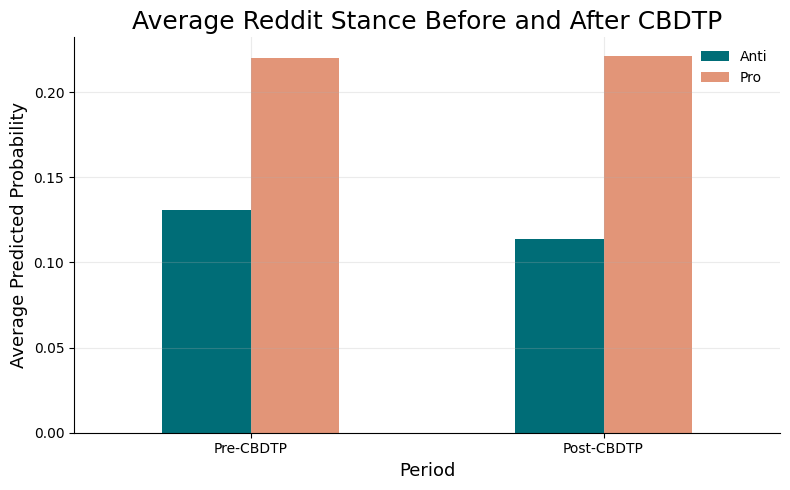

In [29]:
comparison_plot = comparison.set_index("Period")

comparison_plot.plot(
    kind="bar",
    figsize=(8,5)
)


plt.title("Average Reddit Stance Before and After CBDTP")
plt.ylabel("Average Predicted Probability")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Did mobility anomalies become more common after CBDTP? Did the overall frequency of mobility anomalies increase, decrease, or remain stable after congestion pricing was implemented?

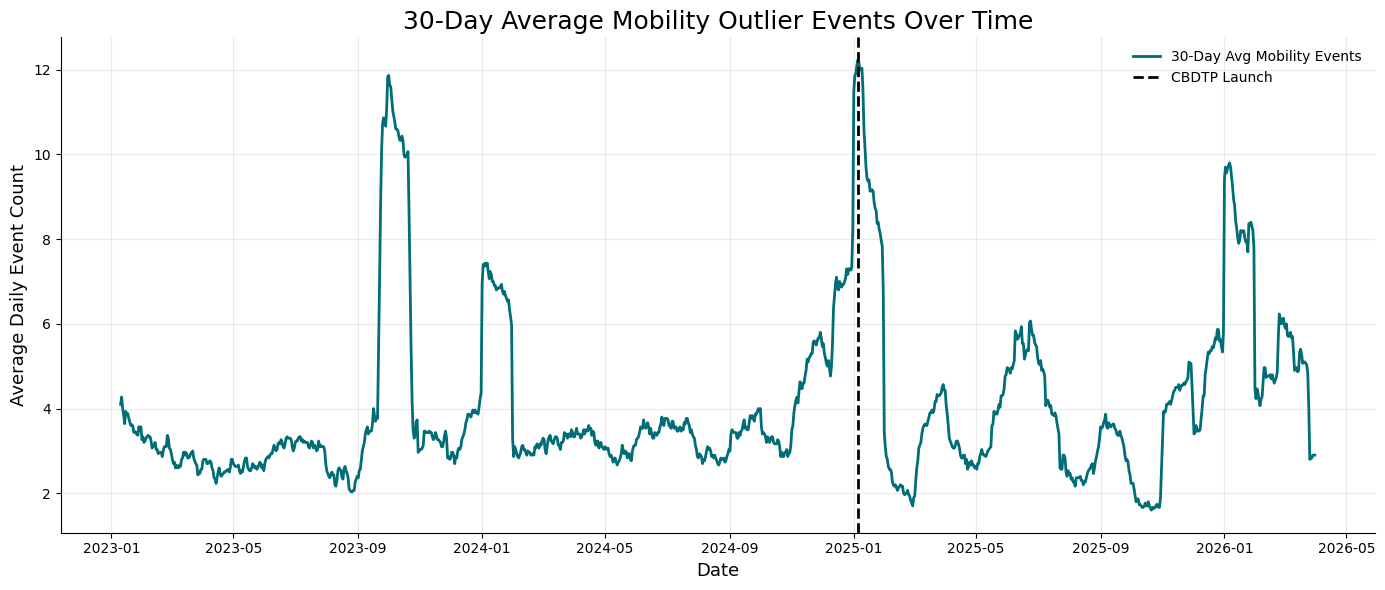

In [31]:
daily["high_confidence_events_30"] = (
    daily["high_confidence_events"]
    .rolling(30, min_periods=10)
    .mean()
)

plt.figure(figsize=(14,6))

plt.plot(
    daily["date"],
    daily["high_confidence_events_30"],
    linewidth=2,
    label="30-Day Avg Mobility Events"
)

plt.axvline(
    pd.Timestamp("2025-01-05"),
    color="black",
    linestyle="--",
    linewidth=2,
    label="CBDTP Launch"
)

plt.title("30-Day Average Mobility Outlier Events Over Time")
plt.xlabel("Date")
plt.ylabel("Average Daily Event Count")
plt.legend()
plt.tight_layout()
plt.show()

Interpretation: The rolling average of mobility anomalies fluctuates over time but does not exhibit a dramatic structural change after the policy launch\. Periods of higher anomaly activity occur both before and after implementation\.

Key Takeaway: Mobility anomalies continued to occur throughout the study period, with no clear evidence that congestion pricing substantially increased or decreased the overall frequency of detected mobility disruptions\.

### 

In [33]:
# Analysis 5 — Event Study: Reddit Stance Around Major Mobility Events



daily = daily.sort_values("date").copy()
daily["date"] = pd.to_datetime(daily["date"])


threshold = daily["high_confidence_events"].quantile(0.90)

event_dates = daily.loc[
    daily["high_confidence_events"] >= threshold,
    "date"
].drop_duplicates()

print("Threshold:", threshold)
print("Number of major event dates:", len(event_dates))

# Build +/- 7 day windows around each event
event_rows = []

for event_date in event_dates:
    for offset in range(-7, 8):
        target_date = event_date + pd.Timedelta(days=offset)
        row = daily[daily["date"] == target_date]

        if not row.empty:
            event_rows.append({
                "event_date": event_date,
                "relative_day": offset,
                "anti_share": row["anti_share"].iloc[0],
                "pro_share": row["pro_share"].iloc[0],
                "neutral_share": row["neutral_share"].iloc[0],
                "reddit_posts": row["reddit_posts"].iloc[0],
                "high_confidence_events": row["high_confidence_events"].iloc[0]
            })

event_window = pd.DataFrame(event_rows)

event_stance_summary = (
    event_window
    .groupby("relative_day")
    .agg(
        avg_anti_share=("anti_share", "mean"),
        avg_pro_share=("pro_share", "mean"),
        avg_neutral_share=("neutral_share", "mean"),
        n_days=("event_date", "count")
    )
    .reset_index()
)

event_stance_summary

Threshold: 7.0
Number of major event dates: 148


,relative_day,avg_anti_share,avg_pro_share,avg_neutral_share,n_days
0,-7,0.126469,0.219932,0.065119,147
1,-6,0.130910,0.224326,0.062670,147
2,-5,0.129309,0.217118,0.067092,147
3,-4,0.129744,0.217294,0.065241,147
4,-3,0.128155,0.217293,0.064591,147
5,-2,0.127547,0.219014,0.061457,147
6,-1,0.132789,0.217379,0.066469,147
7,0,0.124033,0.219496,0.064037,148
8,1,0.128774,0.218151,0.066700,148
9,2,0.131866,0.219709,0.068008,148


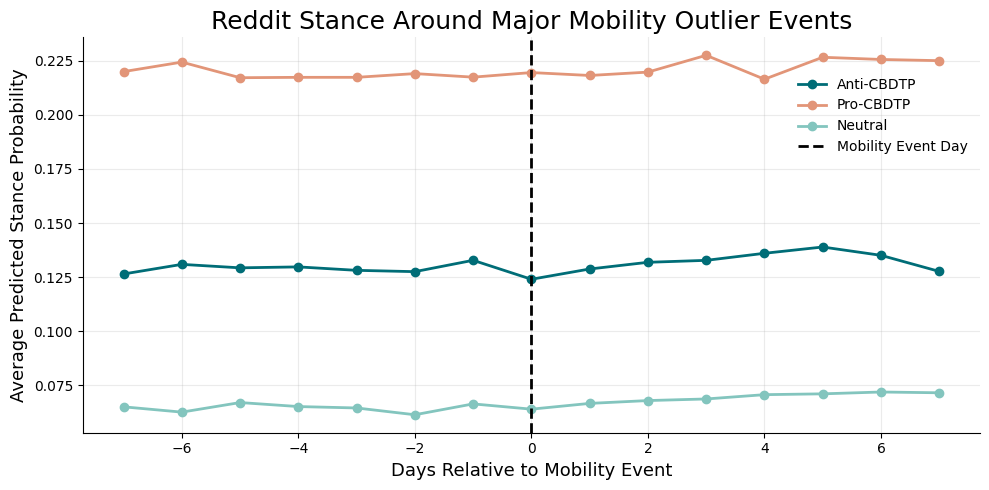

In [35]:
# Plot: stance around major mobility events

plt.figure(figsize=(10, 5))

plt.plot(
    event_stance_summary["relative_day"],
    event_stance_summary["avg_anti_share"],
    marker="o",
    linewidth=2,
    label="Anti-CBDTP"
)

plt.plot(
    event_stance_summary["relative_day"],
    event_stance_summary["avg_pro_share"],
    marker="o",
    linewidth=2,
    label="Pro-CBDTP"
)

plt.plot(
    event_stance_summary["relative_day"],
    event_stance_summary["avg_neutral_share"],
    marker="o",
    linewidth=2,
    label="Neutral"
)

plt.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Mobility Event Day"
)

plt.title("Reddit Stance Around Major Mobility Outlier Events")
plt.xlabel("Days Relative to Mobility Event")
plt.ylabel("Average Predicted Stance Probability")
plt.legend(
    loc="upper right",
    bbox_to_anchor=(1.0, 0.93)
)
plt.tight_layout()
plt.show()

Interpretation: Average pro\-, anti\-, and neutral stance probabilities remain remarkably stable before, during, and after major mobility anomaly events\. No meaningful spikes or sustained changes in sentiment are observed around event dates\.

Key Takeaway: Major mobility disruptions do not appear to meaningfully shift public opinion regarding congestion pricing\. People's views remain largely consistent even during significant transportation events\.

## Analysis 6

In [37]:
# Analysis 6 — Event Study: Reddit Volume Around Major Mobility Events

event_volume_summary = (
    event_window
    .groupby("relative_day")
    .agg(
        avg_reddit_posts=("reddit_posts", "mean"),
        median_reddit_posts=("reddit_posts", "median"),
        n_days=("event_date", "count")
    )
    .reset_index()
)

event_volume_summary

,relative_day,avg_reddit_posts,median_reddit_posts,n_days
0,-7,350.360544,291.0,147
1,-6,332.564626,287.0,147
2,-5,350.673469,302.0,147
3,-4,379.333333,314.0,147
4,-3,386.503401,296.0,147
5,-2,368.176871,257.0,147
6,-1,347.741497,267.0,147
7,0,335.189189,254.5,148
8,1,364.013514,267.5,148
9,2,399.128378,269.5,148


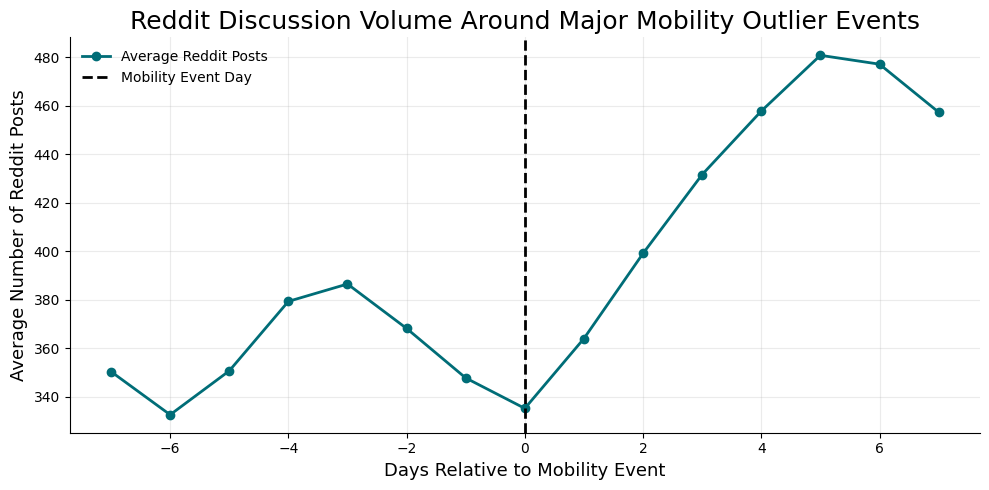

In [39]:
# Plot: discussion volume around major mobility events

plt.figure(figsize=(10, 5))

plt.plot(
    event_volume_summary["relative_day"],
    event_volume_summary["avg_reddit_posts"],
    marker="o",
    linewidth=2,
    label="Average Reddit Posts"
)

plt.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Mobility Event Day"
)

plt.title("Reddit Discussion Volume Around Major Mobility Outlier Events")
plt.xlabel("Days Relative to Mobility Event")
plt.ylabel("Average Number of Reddit Posts")
plt.legend()
plt.tight_layout()
plt.show()

Interpretation: Average Reddit discussion volume rises noticeably in the days following major mobility events before gradually returning toward baseline levels\. This suggests that transportation disruptions stimulate additional public engagement and online conversation\.

Key Takeaway: Unlike sentiment, discussion volume responds strongly to major mobility events\. Transportation disruptions appear to increase public attention and participation without fundamentally changing public opinion\.

# Final Conclusion

Across all analyses, a consistent pattern emerges: mobility anomalies are associated with increases in online discussion but not with meaningful shifts in public sentiment toward congestion pricing\. While transportation disruptions appear to encourage greater public engagement, they largely reinforce existing viewpoints rather than changing them\. Together, these findings suggest that congestion pricing discourse on Reddit is relatively stable, even during periods of significant mobility disruption\.